# Analisi Diffusione COVID-19

Analisi esplorativa e reportistica sui dati della pandemia di COVID-19 raccolti e curati da **Our World in Data**.  
Dataset: [owid-covid-data.csv](https://github.com/owid/covid-19-data/tree/master/public/data)  
Periodo coperto: gennaio 2020 – agosto 2024

## 1. Dimensioni del dataset e metadati

### Caricamento del dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Caricamento file
url = "https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv "
df = pd.read_csv(url)
df

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429430,ZWE,Africa,Zimbabwe,2024-07-31,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429431,ZWE,Africa,Zimbabwe,2024-08-01,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429432,ZWE,Africa,Zimbabwe,2024-08-02,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429433,ZWE,Africa,Zimbabwe,2024-08-03,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN


### EDA Process

In [2]:
print(f"Il dataset presenta {df.shape[0]} righe per {df.shape[1]} colonne")

Il dataset presenta 429435 righe per 67 colonne


In [3]:
print("Analizziamo i metadata:",df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

In [4]:
#La colonna date è in formato object, convertiamola:
df["date"] = pd.to_datetime(df["date"])
df["date"]

0        2020-01-05
1        2020-01-06
2        2020-01-07
3        2020-01-08
4        2020-01-09
            ...    
429430   2024-07-31
429431   2024-08-01
429432   2024-08-02
429433   2024-08-03
429434   2024-08-04
Name: date, Length: 429435, dtype: datetime64[ns]

### **Analisi dei valori `nulli`**

Diverse colonne presentano un'alta percentuale di valori mancanti, in molti casi superiore all'80-90%.  
Questo è atteso: dati come ricoveri ICU, vaccinazioni e test non sono stati rilevati uniformemente da tutti i paesi per tutta la durata della pandemia.

In [5]:
#calcoliamo la percentuale di valori che mancano
percentuale_mancanti = (df.isnull().sum() / len(df)) * 100
#filtriamo e facciamo vedere solo quelli che hanno una percentuale sopra il 50%
mancanti_sopra_50 = percentuale_mancanti[percentuale_mancanti > 50].sort_values(ascending=False)

print("Le colonne con valori mancanti > 50% sono:\n",mancanti_sopra_50)

Le colonne con valori mancanti > 50% sono:
 weekly_icu_admissions                         97.440125
weekly_icu_admissions_per_million             97.440125
excess_mortality_cumulative_per_million       96.877059
excess_mortality                              96.877059
excess_mortality_cumulative_absolute          96.877059
excess_mortality_cumulative                   96.877059
weekly_hosp_admissions                        94.295528
weekly_hosp_admissions_per_million            94.295528
icu_patients_per_million                      90.891287
icu_patients                                  90.891287
hosp_patients                                 90.532677
hosp_patients_per_million                     90.532677
total_boosters_per_hundred                    87.518484
total_boosters                                87.518484
new_vaccinations                              83.473401
new_tests_per_thousand                        82.441347
new_tests                                     82.441347
peop

### **Analisi colonna `"location"`**

In [70]:
print(f"La colonna location presenta {df['location'].value_counts().sum()} valori non nulli e {df['location'].isnull().sum()} nulli.")

La colonna location presenta 429435 valori non nulli e 0 nulli.


### **Analisi colonna `"continent"`**

In [7]:
print(f"La colonna continent presenta {df['continent'].value_counts().sum()} valori non nulli e {df['continent'].isnull().sum()} nulli, \ni valori di questa colonna sono (tolti i nulli) {df['continent'].dropna().unique()}.")

La colonna continent presenta 402910 valori non nulli e 26525 nulli, 
i valori di questa colonna sono (tolti i nulli) ['Asia' 'Europe' 'Africa' 'Oceania' 'North America' 'South America'].


In [8]:
#isoliamo i valori nulli e analizziamo come possiamo sistemarli
df_continent_nulli = df[df['continent'].isnull()]

#vediamo se riusciamo a intercettarli con la colonna "location"
df_location_continent_nulli = df_continent_nulli['location'].unique()
print(f"I valori nulli di continent in Location sono {df_location_continent_nulli}")

I valori nulli di continent in Location sono ['Africa' 'Asia' 'Europe' 'European Union (27)' 'High-income countries'
 'Low-income countries' 'Lower-middle-income countries' 'North America'
 'Oceania' 'South America' 'Upper-middle-income countries' 'World']


In [9]:
#non faccio uno spostamento di valori ma mi creo due dataset
df_nazioni = df[df['continent'].notnull()].copy()

df_macro = df[df['continent'].isnull()].copy()

print(f"Dataset nazioni pronto: {df_nazioni.shape[0]} righe.")
print(f"Dataset aggregati isolato: {df_macro.shape[0]} righe.")

#verifichiamo i valori se sono uguali:
casi_nazioni = df_nazioni.groupby(['continent', 'location'])['total_cases'].last().groupby('continent').sum()
casi_macro = df_macro[df_macro['location'] == 'Europe']['total_cases'].max()

print(f"Il totale dei casi in europa del primo dataframe sono {casi_nazioni.loc['Europe']} mentre quelli del secondo sono {casi_macro}.")

#ricapitolando
#df è il mio dataframe grezzo
#df_nazioni è il mio dataframe principale
#df_macro lo suo nel caso mi servisse controllare i valori ufficiali aggregati

Dataset nazioni pronto: 402910 righe.
Dataset aggregati isolato: 26525 righe.
Il totale dei casi in europa del primo dataframe sono 252916868.0 mentre quelli del secondo sono 252916868.0.


### **Analisi delle colonne `"new_cases"` e `"total_cases"`**

Le due colonne hanno logiche differenti e vanno trattate diversamente:

| Colonna | Tipo | Logica |
|---|---|---|
| `new_cases` | **Flusso** | Nuovi casi registrati nel periodo (settimanale per molti paesi) — i giorni senza rilevazione valgono 0 |
| `total_cases` | **Stock** | Valore cumulato progressivo — i NaN vengono propagati con `ffill()` per nazione |

In [10]:
#print(df_nazioni[['date', 'total_cases','new_cases']].tail(35))
filtro_new_cases = df_nazioni['new_cases'] > 0
df_positivi_analisi = df_nazioni[filtro_new_cases]
print(df_positivi_analisi[['location', 'date', 'new_cases', 'total_cases']].head(5))

       location       date  new_cases  total_cases
56  Afghanistan 2020-03-01        1.0          1.0
70  Afghanistan 2020-03-15        6.0          7.0
77  Afghanistan 2020-03-22       17.0         24.0
84  Afghanistan 2020-03-29       67.0         91.0
91  Afghanistan 2020-04-05      183.0        274.0


In [11]:
#analizziamo i nulli
nulli_new = df_nazioni['new_cases'].isnull().sum()
nulli_total = df_nazioni['total_cases'].isnull().sum()
print(f"Valori nulli in new_cases: {nulli_new}")
print(f"Valori nulli in total_cases: {nulli_total}")

print("\nData types delle due colonne:")
print(df_nazioni[['new_cases', 'total_cases']].dtypes)

df_test_pulizia = df_nazioni.copy()
df_test_pulizia['new_cases'] = df_test_pulizia['new_cases'].fillna(0)
nulli_new_test = df_test_pulizia['new_cases'].isnull().sum()
print(f"Valori nulli in new_cases: {nulli_new_test}")

df_test_pulizia['total_cases_fillato'] = df_test_pulizia.groupby('location')['total_cases'].ffill()
df_test_pulizia['total_cases_fillato'] = df_test_pulizia['total_cases_fillato'].fillna(0)

print("\n--- Test prima e dopo (Finestra temporale) ---")
test_italy = df_test_pulizia[df_test_pulizia['location'] == 'Italy']
#faccio un test su quando effettivamente la pandemia è iniziata in italia
test_it_pand = test_italy[(test_italy['date'] >= '2020-01-30') & (test_italy['date'] <= '2020-02-05')]
print(test_it_pand[['date', 'total_cases', 'total_cases_fillato']])

#test invece solo sulle righe riparate
print("--- Test prima e dopo (Solo righe riparate) per i NaN ---")
test_italy_ripar = df_test_pulizia[(df_test_pulizia['location'] == 'Italy') & (df_test_pulizia['total_cases'].isna())]
print(test_italy_ripar[['date', 'total_cases', 'total_cases_fillato']].head(10))


#Test ok riassegnamo le variabili
df_nazioni['new_cases'] = df_test_pulizia['new_cases']
df_nazioni['total_cases'] = df_test_pulizia['total_cases_fillato']
#verifichiamo di nuovo
nulli_new_post = df_nazioni['new_cases'].isnull().sum()
nulli_total_post = df_nazioni['total_cases'].isnull().sum()
print(f"Valori nulli in new_cases post modifiche: {nulli_new_post}")
print(f"Valori nulli in total_cases post modifiche: {nulli_total_post}")

Valori nulli in new_cases: 12839
Valori nulli in total_cases: 11194

Data types delle due colonne:
new_cases      float64
total_cases    float64
dtype: object
Valori nulli in new_cases: 0

--- Test prima e dopo (Finestra temporale) ---
             date  total_cases  total_cases_fillato
185300 2020-01-30          0.0                  0.0
185301 2020-01-31          0.0                  0.0
185302 2020-02-01          0.0                  0.0
185303 2020-02-02          3.0                  3.0
185304 2020-02-03          3.0                  3.0
185305 2020-02-04          3.0                  3.0
185306 2020-02-05          3.0                  3.0
--- Test prima e dopo (Solo righe riparate) per i NaN ---
             date  total_cases  total_cases_fillato
186949 2024-08-05          NaN           26781078.0
186950 2024-08-06          NaN           26781078.0
186951 2024-08-07          NaN           26781078.0
Valori nulli in new_cases post modifiche: 0
Valori nulli in total_cases post modif

In [12]:
#facciamo lo stesso su df_macro
df_macro['new_cases'] = df_macro['new_cases'].fillna(0)
df_macro['total_cases'] = df_macro.groupby('location')['total_cases'].ffill()
df_macro['total_cases'] = df_macro['total_cases'].fillna(0)

### **Analisi dei duplicati**

In [13]:
duplicati = df_nazioni.duplicated().sum()
print(f"Il numero di righe duplicate trovate: {duplicati}")

Il numero di righe duplicate trovate: 0


## 2. Casi per continente dall'inizio della pandemia

Per ogni continente: numero totale di casi e percentuale rispetto al totale mondiale.  

In [14]:
#continenti = df_nazioni["continent"].unique()
casi_per_continente = df_nazioni.groupby(['continent', 'location'])['total_cases'].last().groupby('continent').sum()
totale_casi = casi_per_continente.sum()

for continente, casi in casi_per_continente.items():
    percentuale = (casi / totale_casi) * 100
    print(f"In {continente} ci sono stati {casi:,.0f} casi, che sono il {percentuale:.2f}% del totale mondiale")

In Africa ci sono stati 13,145,380 casi, che sono il 1.69% del totale mondiale
In Asia ci sono stati 301,499,099 casi, che sono il 38.86% del totale mondiale
In Europe ci sono stati 252,916,868 casi, che sono il 32.60% del totale mondiale
In North America ci sono stati 124,492,666 casi, che sono il 16.05% del totale mondiale
In Oceania ci sono stati 15,003,352 casi, che sono il 1.93% del totale mondiale
In South America ci sono stati 68,809,418 casi, che sono il 8.87% del totale mondiale


## 3. Italia 2022 — Analisi dei casi

Vengono selezionati i dati relativi all'Italia nel 2022. Poiché i nuovi casi vengono registrati settimanalmente, i giorni senza misurazione (`new_cases == 0`) vengono esclusi.

In [69]:
df_nazioni["anno"] = df_nazioni["date"].dt.year
df_italia_2022 = df_nazioni[(df_nazioni["anno"] == 2022) & (df_nazioni["location"] == "Italy")].copy()

df_italia_2022 = df_italia_2022[df_italia_2022["new_cases"] > 0]

display(df_italia_2022.head())

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million,anno
186003,ITA,Europe,Italy,2022-01-02,6267035.0,644604.0,92086.29,137513.0,983.0,140.43,...,NaN,3.18,83.51,0.89,59037472,168226.30,12.99,8.06,2849.48,2022
186010,ITA,Europe,Italy,2022-01-09,7281297.0,1014262.0,144894.57,138881.0,1368.0,195.43,...,NaN,3.18,83.51,0.89,59037472,168831.80,12.89,3.94,2859.74,2022
186017,ITA,Europe,Italy,2022-01-16,8549450.0,1268153.0,181164.71,140856.0,1975.0,282.14,...,NaN,3.18,83.51,0.89,59037472,170089.10,12.83,8.03,2881.04,2022
186024,ITA,Europe,Italy,2022-01-23,9781191.0,1231741.0,175963.00,143296.0,2440.0,348.57,...,NaN,3.18,83.51,0.89,59037472,171694.19,12.80,10.40,2908.22,2022
186031,ITA,Europe,Italy,2022-01-30,10821375.0,1040184.0,148597.71,145914.0,2618.0,374.00,...,NaN,3.18,83.51,0.89,59037472,174151.69,12.84,16.50,2949.85,2022


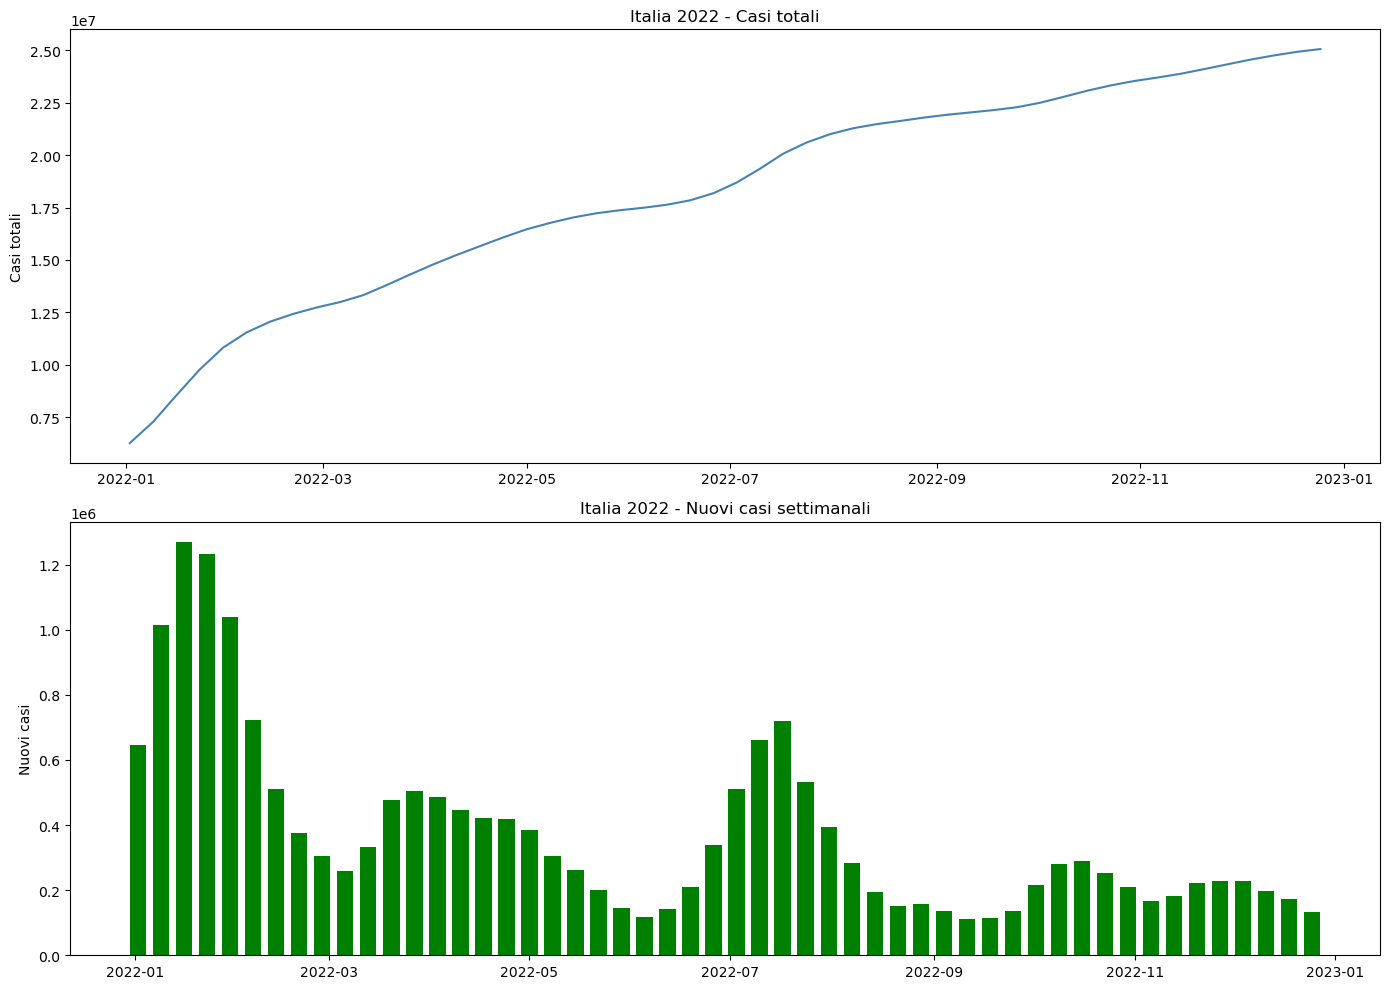

In [17]:
fig, (n1, n2) = plt.subplots(2, 1, figsize=(14, 10))

# a) Evoluzione total_cases
n1.plot(df_italia_2022['date'], df_italia_2022['total_cases'], color='steelblue')
n1.set_title('Italia 2022 - Casi totali')
n1.set_ylabel('Casi totali')

# b) Nuovi casi settimanali
n2.bar(df_italia_2022['date'], df_italia_2022['new_cases'], color='green', width=5)
n2.set_title('Italia 2022 - Nuovi casi settimanali')
n2.set_ylabel('Nuovi casi')

plt.tight_layout()
plt.show()

### a) Evoluzione dei casi totali
`total_cases` è uno stock cumulato --> la linea cresce nel corso dell'anno.

### b) Nuovi casi settimanali
`new_cases` è un flusso --> le barre mostrano la cadenza settimanale e le ondate del 2022.

## 4. Pazienti in terapia intensiva — Italia, Germania, Francia (mag 2022 / apr 2023)

### **Analisi colonna `icu_patients`**

In [32]:
print(f"La colonna icu_patients presenta {df_nazioni['icu_patients'].value_counts().sum()} valori non nulli e {df_nazioni['icu_patients'].isnull().sum()} nulli.")
print(df_nazioni['icu_patients'].describe())

# Distribuzione per nazione: ci sono nazioni con troppi nulli?
df_verifica = df_nazioni.groupby('location')['icu_patients'].agg(['count', 'size'])
df_verifica
nazioni = df_verifica.loc[['Italy', 'Germany', 'France']]
nazioni


La colonna location presenta 39116 valori non nulli e 363794 nulli.
count    39116.000000
mean       660.971418
std       2139.615532
min          0.000000
25%         21.000000
50%         90.000000
75%        413.000000
max      28891.000000
Name: icu_patients, dtype: float64


,count,size
location,,
Italy,1627,1677
Germany,1194,1674
France,1109,1674


**Pulizia**

In [43]:
nazioni_filtro = ['Italy', 'Germany', 'France']
df_icu = df_nazioni[(df_nazioni['location'].isin(nazioni_filtro)) & (df_nazioni['date'] >= '2022-05-01') & (df_nazioni['date'] <= '2023-04-30')].copy()

# ffill per nazione, non su tutto il df
df_icu['icu_patients'] = df_icu.groupby('location')['icu_patients'].ffill()
print(f"La colonna icu_patients presenta {df_icu['icu_patients'].value_counts().sum()} valori non nulli e {df_icu['icu_patients'].isnull().sum()} nulli.")

display(df_icu['icu_patients'].describe())

La colonna icu_patients presenta 1095 valori non nulli e 0 nulli.


count    1095.000000
mean      742.745205
std       426.833501
min        82.000000
25%       311.000000
50%       761.000000
75%      1050.000000
max      1842.000000
Name: icu_patients, dtype: float64

La colonna icu_patients presenta valori nulli non imputabili a zero, in quanto assenza di dato e assenza di pazienti sono concettualmente distinte. Si è scelto di applicare forward fill per propagare l'ultimo valore noto, una scelta ragionevole data la lenta variabilità giornaliera dei ricoveri in terapia intensiva.

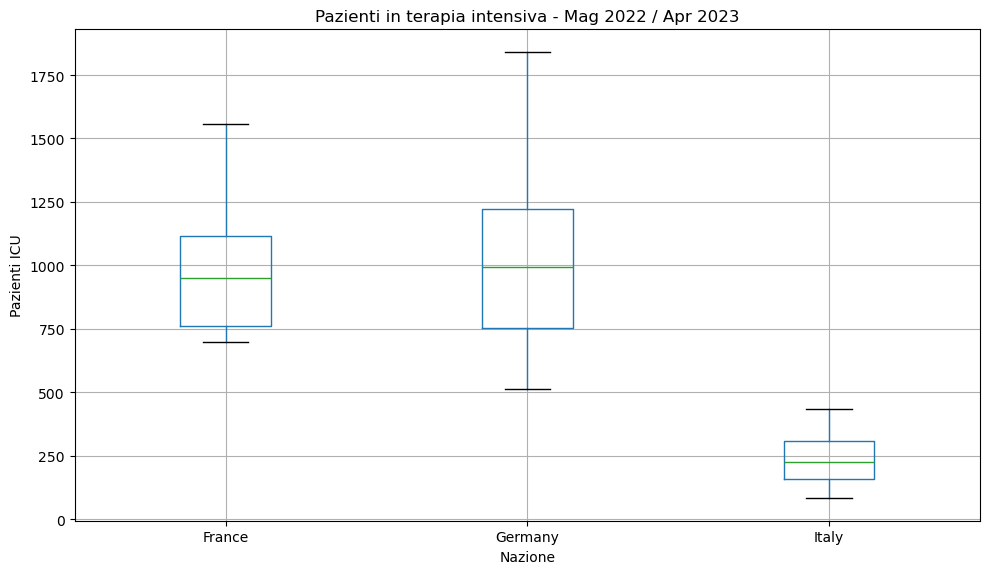

In [45]:
fig, n3 = plt.subplots(figsize=(10, 6))

df_icu.boxplot(column='icu_patients', by='location', ax=n3)

n3.set_title('Pazienti in terapia intensiva - Mag 2022 / Apr 2023')
n3.set_xlabel('Nazione')
n3.set_ylabel('Pazienti ICU')
plt.suptitle('')
plt.tight_layout()
plt.show()

### Osservazioni

Italia presenta una pressione sulle terapie intensive nettamente inferiore rispetto a Francia e Germania, con una mediana di circa 230 pazienti ICU contro i ~950-1000 delle altre due nazioni. 
Francia e Germania mostrano valori mediani simili, ma la Germania ha una dispersione maggiore, indicando una maggiore variabilità nel periodo osservato.

> ⚠️ I valori assoluti non tengono conto delle differenze di popolazione tra i paesi. Per un confronto più rigoroso si utilizza la colonna `icu_patients_per_million`, già disponibile nel dataset.

In [47]:
df_verifica_icu_million = df_nazioni[df_nazioni['location'].isin(nazioni_filtro)].groupby('location')['icu_patients_per_million'].agg(['count', 'size'])

print(df_verifica_icu_million)

          count  size
location             
France     1109  1674
Germany    1194  1674
Italy      1627  1677


In [48]:
df_icu['icu_patients_per_million'] = df_icu.groupby('location')['icu_patients_per_million'].ffill()
# verifica
print(df_icu.groupby('location')['icu_patients_per_million'].agg(['count', 'size']))

          count  size
location             
France      365   365
Germany     365   365
Italy       365   365


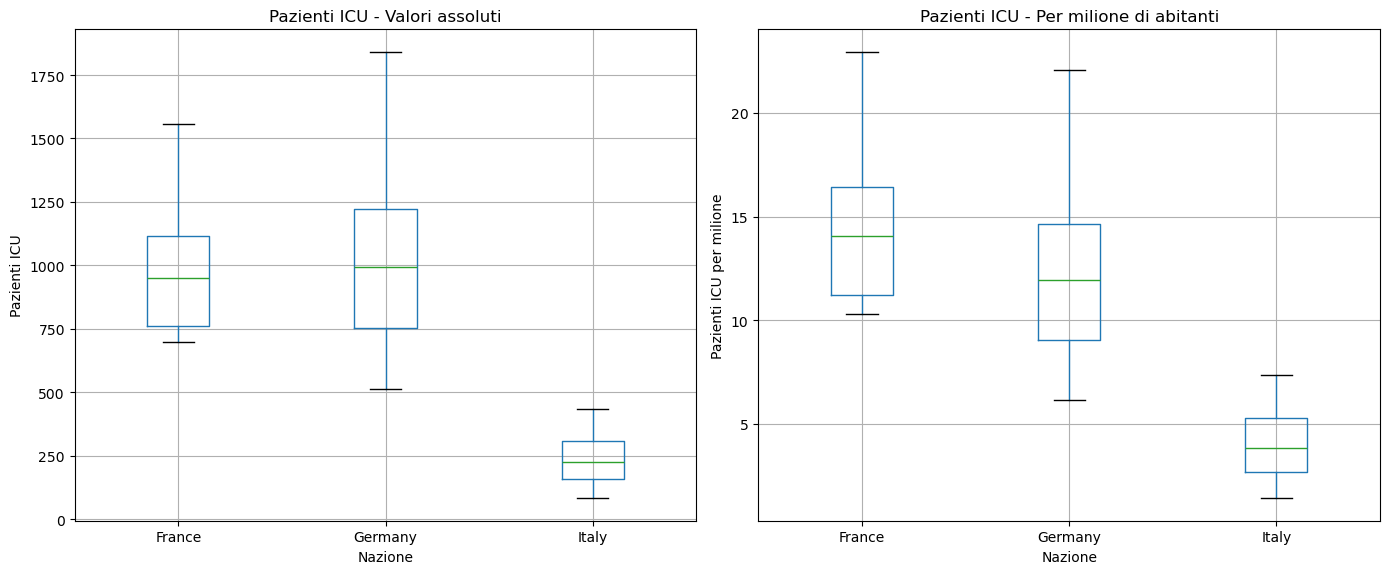

In [52]:
fig, (n4, n5) = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot valori assoluti
df_icu.boxplot(column='icu_patients', by='location', ax=n4)
n4.set_title('Pazienti ICU - Valori assoluti')
n4.set_xlabel('Nazione')
n4.set_ylabel('Pazienti ICU')
plt.suptitle('')

# Boxplot normalizzato per milione
df_icu.boxplot(column='icu_patients_per_million', by='location', ax=n5)
n5.set_title('Pazienti ICU - Per milione di abitanti')
n5.set_xlabel('Nazione')
n5.set_ylabel('Pazienti ICU per milione')
plt.suptitle('')

plt.tight_layout()
plt.show()

### Osservazioni
In valori assoluti Germania e Francia mostrano una pressione ICU simile (circa 950-1000 pazienti), mentre l'Italia risulta nettamente inferiore (circa 230). 
Normalizzando per milione di abitanti il quadro cambia: la Francia supera la Germania (mediana di circa 14 vs 12 per milione), suggerendo che in termini relativi il sistema sanitario francese ha subito una pressione maggiore. 
L'Italia rimane la nazione con il minor carico ICU anche nella lettura normalizzata (circa 4 per milione), dato che potrebbe riflettere differenze nelle politiche di rilevazione o nella capacità di gestione territoriale.

## 5. Pazienti ospedalizzati — Italia, Germania, Francia, Spagna (2021)

In [64]:
nazioni_filtro_2 = ['Italy', 'Germany', 'France', 'Spain']
df_hosp = df_nazioni[(df_nazioni["anno"] == 2021) & (df_nazioni["location"].isin(nazioni_filtro_2))]
print(f"La colonna hosp_patients presenta {df_hosp['hosp_patients'].value_counts().sum()} valori non nulli e {df_hosp['hosp_patients'].isnull().sum()} nulli.")

#capiamo dove sono i nulli
print(df_hosp.groupby('location')['hosp_patients'].agg(['count', 'size']))

#escludiamo la Germania perchè non ha valori, non è un buco di rilevazione colmabile ma magari non c'è stata rilevazione in quell'anno
df_hosp = df_hosp.dropna(subset=['hosp_patients'])
print(df_hosp.groupby('location')['hosp_patients'].agg(['count', 'size']))

La colonna hosp_patients presenta 1095 valori non nulli e 365 nulli.
          count  size
location             
France      365   365
Germany       0   365
Italy       365   365
Spain       365   365
          count  size
location             
France      365   365
Italy       365   365
Spain       365   365


La colonna hosp_patients per la Germania risulta completamente assente nel 2021 (0 valori su 365 giorni). Non si tratta di buchi sporadici colmabili con forward fill, ma di un dato strutturalmente non rilevato o non comunicato per quell'anno. La Germania viene pertanto esclusa dall'analisi, che procede con Italia, Francia e Spagna

In [65]:
hosp_sommati = df_hosp.groupby('location')['hosp_patients'].sum()
print(hosp_sommati)

location
France    6008717.0
Italy     4419950.0
Spain     2411706.0
Name: hosp_patients, dtype: float64


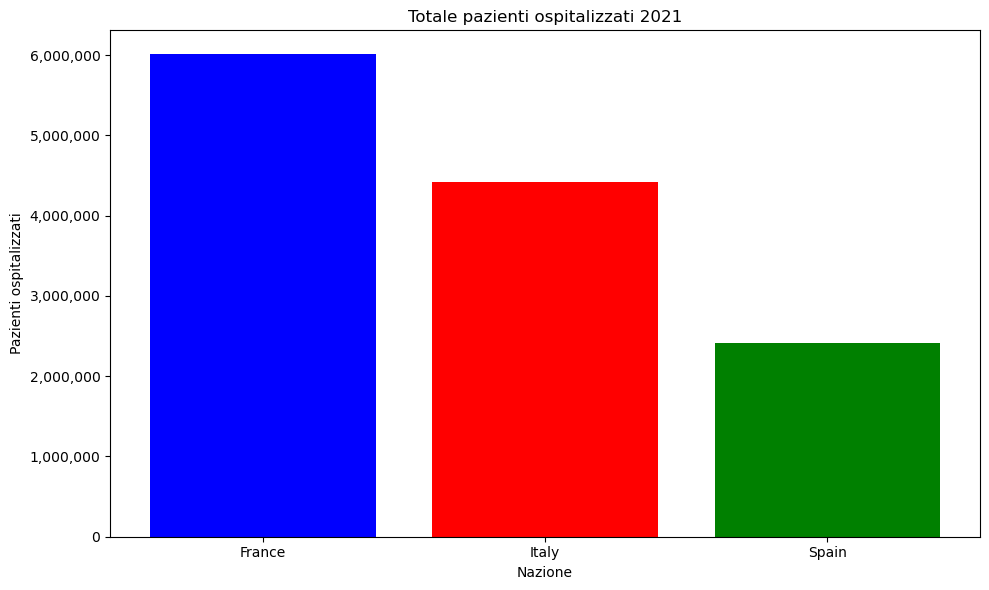

In [68]:
fig, n5 = plt.subplots(figsize=(10, 6))

n5.bar(hosp_sommati.index, hosp_sommati.values, color=['blue', 'red', 'green'])
n5.set_title('Totale pazienti ospitalizzati 2021')
n5.set_xlabel('Nazione')
n5.set_ylabel('Pazienti ospitalizzati')
n5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

### Osservazioni
La Francia registra il maggior numero di pazienti ospitalizzati nel 2021 (circa 6M), seguita dall'Italia (circa 4.4M) e dalla Spagna (circa 2.4M). 
Anche in questo caso i valori assoluti non sono normalizzati per popolazione.

La Germania è stata **esclusa dall'analisi** in quanto la colonna `hosp_patients` risulta completamente assente per tutto il 2021 (0 valori su 365 giorni). Non si tratta di buchi colmabili con `ffill()`, ma di un dato strutturalmente non rilevato o non comunicato per quell'anno.